# Is the asteroid belt's compositional gradient primordial?

**SPS 4045 term paper — analysis notebook.** Logan Edwards.

The static-nebula picture predicts a clean transition from dry, thermally processed S-types inside the snow line to hydrated C-types outside it. This notebook measures what the belt actually shows and tests the prediction that separates *formed-in-place* from *implanted* (Grand Tack, Walsh et al. 2011; empty-belt implantation, Raymond & Izidoro 2017).

| § | What it does |
|---|---|
| 1 | Load the AsteroidCatalog snapshot; keep only **trustworthy** labels |
| 2 | Group Bus–DeMeo classes into compositional groups |
| 3 | Load Nesvorný et al. (2015, 2024) HCM families; match, de-duplicate, optionally extend |
| 4 | Measure label completeness vs *H*; derive a size-complete cut and inverse-completeness weights |
| 5 | **Fig 1** — C-fraction vs *a*: raw → family-collapsed → debiased |
| 6 | **Fig 2** — the same by mass |
| 7 | S/C crossover location with bootstrap CI, vs the 2.7 AU snow line |
| 8 | **Fig 3** — orbital excitation (proper *e*, sin *i*) of S vs C within each zone |
| 9 | Robustness: group definitions, label-free albedo check, family extension, circularity demo |
| 10 | Summary numbers → `results/summary.json` |

Every figure is written to `../figures/`. Change the knobs in the config cell and re-run top to bottom.

In [1]:
from pathlib import Path
import json, re, glob, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="All-NaN slice")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

# ── paths ───────────────────────────────────────────────────────────────────
ROOT      = Path(r"C:/Users/Loggg/OneDrive/Documents/Se Fall/Planet formation/term_paper")
if Path.cwd().name == "analysis" and (Path.cwd().parent / "data").exists():
    ROOT = Path.cwd().parent                     # portable when run from term_paper/analysis
DATA      = ROOT / "data"
FIG       = ROOT / "figures";  FIG.mkdir(exist_ok=True)
RES       = ROOT / "results";  RES.mkdir(exist_ok=True)
NESV      = DATA / "ast.nesvorny.families_V2_0" / "data"
SOURCE_CSV = Path(r"C:/Users/Loggg/OneDrive/Documents/GitHub/economicspace/asteroid_pipeline/asteroid_catalog.csv")
SNAPSHOT  = DATA / "catalog_snapshot.parquet"   # frozen copy: the upstream build cannot be refetched identically

# ── analysis knobs ──────────────────────────────────────────────────────────
A_MIN, A_MAX   = 2.1, 3.3          # main belt, AU
Q_MIN          = 1.3               # perihelion floor: drop Mars-crossers
ZONES          = [2.1, 2.5, 2.82, 2.96, 3.3]            # inner | middle | pristine | outer (Kirkwood gaps)
ZONE_NAMES     = ["inner", "middle", "pristine", "outer"]
KIRKWOOD       = {"3:1": 2.502, "5:2": 2.825, "7:3": 2.958, "2:1": 3.278}
SNOW_LINE_AU   = (278 / 170) ** 2  # T_eq = 278 K (a/1 AU)^-1/2 = 170 K  -> 2.67 AU
BIN_W          = 0.05              # AU, for fraction-vs-a curves
COMPLETE_FRAC  = 0.95              # label completeness required for the size-complete sample
P_DARKEST      = 0.04              # darkest plausible albedo, sets D_complete
H_IPW_MAX      = 15.0              # IPW: labelled bodies must sit in an H bin brighter than this...
D_IPW          = 10.0              # km; IPW sample is SIZE-limited (dark 10 km body has H~14.1 < H_IPW_MAX)
C_MIN_IPW      = 0.30              # ...and completeness >= this
D_ORBIT        = 10.0              # km, size floor for the orbital-excitation test
EXTEND_FAMILIES = False            # one-step nearest-member extension (sensitivity test, §9)
N_BOOT         = 300
RNG            = np.random.default_rng(4045)

COLORS = {"S-like": "#c0392b", "C-like": "#2c3e50", "D/P": "#7d5a3c", "K/L": "#d68910", "X": "#8e8e8e", "other": "#cccccc"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "axes.titlepad": 16})

def mark_structure(ax, snow=True):
    for k, a in KIRKWOOD.items():
        if A_MIN < a < A_MAX:
            ax.axvline(a, color="k", ls=":", lw=0.8, alpha=0.6)
            ax.text(a, 1.01, k, transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=7, color="0.35")
    if snow:
        ax.axvline(SNOW_LINE_AU, color="#2e86c1", ls="--", lw=1)

## 1 · Catalog and label provenance

The catalog assigns a spectral type to ~every body, but by three very different routes (`spectral_type_source`):

| tier | route | used here? |
|---|---|---|
| `source` | a published taxonomic classification (SsODNet: SDSS/Gaia/spectroscopic surveys) | **yes — primary** |
| `albedo` | *measured* albedo thresholded: p<0.10→C, <0.35→S, else V | robustness only (dark/bright proxy) |
| `albedo_assumed` | albedo **assumed from semimajor axis** (`ALBEDO_BY_SEMI_MAJOR_AXIS_AU`), then thresholded | **never** — it re-encodes the gradient being tested (demonstrated in §9d) |

In [2]:
COLS = ["designation", "name", "spectral_type", "spectral_type_source", "semi_major_axis_au", "eccentricity",
        "inclination_deg", "perihelion_au", "diameter_km", "diameter_source", "albedo", "absolute_magnitude_h",
        "estimated_mass_kg", "mass_measured", "catalog_date", "pipeline_version"]

if not SNAPSHOT.exists():
    raw = pd.read_csv(SOURCE_CSV, usecols=COLS, dtype={"designation": str, "name": str}, low_memory=False)
    raw.to_parquet(SNAPSHOT, index=False)
cat = pd.read_parquet(SNAPSHOT)
print(f"snapshot: {len(cat):,} rows | catalog_date {cat.catalog_date.iloc[0]} | pipeline {cat.pipeline_version.iloc[0]}")

norm_key = lambda s: s.astype(str).str.replace(" ", "", regex=False).str.upper()
cat["key"] = norm_key(cat["designation"])

mb = cat[cat.semi_major_axis_au.between(A_MIN, A_MAX) & (cat.perihelion_au > Q_MIN)].copy()
mb["zone"] = pd.cut(mb.semi_major_axis_au, ZONES, labels=ZONE_NAMES)
print(f"main belt ({A_MIN}-{A_MAX} AU, q>{Q_MIN}): {len(mb):,}")
print(mb.spectral_type_source.value_counts().to_string())

snapshot: 1,555,667 rows | catalog_date 2026-08-11 | pipeline 1.1.0


main belt (2.1-3.3 AU, q>1.3): 1,431,660
spectral_type_source
albedo_assumed    1189706
source             161646
albedo              80304
unknown                 4


## 2 · Compositional groups

Grouped on the first letter of the Bus–DeMeo / Gaia class. **K and L** are kept apart: they are anhydrous but linked to CV/CO carbonaceous chondrites, so assigning them to either side is a choice — §9a checks both. **X** is excluded from the S/C fraction (without albedo it spans enstatite, metal, and primitive P-like bodies).

Two headline definitions of "carbonaceous":
- **narrow**: C-like / (S-like + C-like)
- **broad**: (C-like + D/P + K/L) / (S-like + C-like + D/P + K/L)

In [3]:
GROUP_OF_LETTER = {**dict.fromkeys(list("SQAVRO"), "S-like"), **dict.fromkeys(list("CB"), "C-like"),
                   **dict.fromkeys(list("DPT"), "D/P"), **dict.fromkeys(list("KL"), "K/L"),
                   **dict.fromkeys(list("XME"), "X")}
def to_group(t):
    return t.astype(str).str[0].map(GROUP_OF_LETTER).fillna("other")

mb["group"] = to_group(mb.spectral_type)
mb["tier"]  = mb.spectral_type_source.map({"source": "taxonomy", "albedo": "albedo_proxy", "albedo_assumed": "assumed"}).fillna("none")
tax = mb.tier.eq("taxonomy")
print(pd.crosstab(mb.loc[tax, "zone"], mb.loc[tax, "group"], margins=True))

group     C-like   D/P   K/L  S-like      X  other     All
zone                                                      
inner      12207   871  2507   37483   2896     12   55976
middle     16954  1486  3423   31989   4460      2   58314
pristine    2043   201   387    3112    773      3    6519
outer      21999  1681  1936    9582   5632      7   40837
All        53203  4239  8253   82166  13761     24  161646


## 3 · Collisional families

Families are single parent bodies shattered into hundreds to thousands of catalogued fragments. Counting fragments measures *which bodies happened to break*, not *what formed where*, so families must be removed or collapsed.

Membership comes from the Nesvorný HCM catalogue (PDS SBN bundle `ast.nesvorny.families` V2.0): 119 families from Nesvorný et al. (2015, numbered asteroids only) plus 153 new families from Nesvorný, Roig, Vokrouhlický & Brož (2024). A body listed in two families (nested clusters such as Karin inside Koronis) is assigned to the **larger** one. Proper elements for §8 come from the same bundle (`proper_catalog24.tab`, 1.25 M orbits).

**Caveat:** the 2015 lists only contain asteroids numbered by 2015. This matters little for the size-limited samples (large bodies were numbered long ago) and is bounded by the optional one-step extension (`EXTEND_FAMILIES`, §9c).

In [4]:
# ── 2015 families: list + members ───────────────────────────────────────────
fl_rows = []
for line in open(NESV / "familylist.tab"):
    m = re.match(r"^(\d{3})\s+(\d+)\s+(.*?)\s+(\d+)\s+(\d+)\s+[\d.]+", line)
    if m:
        fl_rows.append(dict(fam_id=f"2015_{m[1]}", parent_num=m[2], fam_name=m[3].strip(), cutoff=float(m[4])))
fams15 = pd.DataFrame(fl_rows)

mem = []
for f in glob.glob(str(NESV / "families_2015" / "*.tab")):
    for line in open(f):
        t = line.split()
        if len(t) >= 7:
            mem.append((t[0], f"2015_{t[6]}"))
mem15 = pd.DataFrame(mem, columns=["key", "fam_id"])

# ── 2024 families: cutoffs from the document list, members from csvs ───────
cut24 = {}
for line in open(NESV.parent / "document" / "list_of_new_families_2024.txt"):
    m = re.match(r"^(\d+)\s+(.*?)\s+(\d+)\s+(\d+)(\s+\S+)?\s*$", line.strip())
    if m:
        cut24[m[1]] = (m[2], float(m[3]))
rows, mem = [], []
for f in glob.glob(str(NESV / "families_2024" / "*.csv")):
    stem = Path(f).stem                       # e.g. middle_177_irma_fam3
    parts = stem.split("_")
    pnum = parts[1]
    name, cut = cut24.get(pnum, (parts[2], np.nan))
    fid = f"2024_{stem}"
    rows.append(dict(fam_id=fid, parent_num=pnum, fam_name=name, cutoff=cut))
    x = pd.read_csv(f, header=None, dtype=str)
    mem += [(k, fid) for k in x[8]]
fams24 = pd.DataFrame(rows); mem24 = pd.DataFrame(mem, columns=["key", "fam_id"])

fams = pd.concat([fams15, fams24], ignore_index=True)
assert fams.fam_id.is_unique, fams.fam_id[fams.fam_id.duplicated()].tolist()
members = pd.concat([mem15, mem24], ignore_index=True)
members["key"] = norm_key(members["key"])
fams["n_listed"] = fams.fam_id.map(members.fam_id.value_counts()).fillna(0).astype(int)
print(f"families: {len(fams15)} (2015) + {len(fams24)} (2024) | cutoff missing for {fams.cutoff.isna().sum()}")

# de-duplicate: a body in two families goes to the larger one
members = (members.merge(fams[["fam_id", "n_listed"]], on="fam_id")
                  .sort_values("n_listed", ascending=False).drop_duplicates("key"))
print(f"unique family members: {len(members):,}")

# ── proper elements ────────────────────────────────────────────────────────
pc = pd.read_csv(NESV / "proper_catalog24.tab", sep=r"\s+", header=None, dtype={10: str, 11: str},
                 usecols=[0, 2, 4, 8, 11], names=["a_p", "e_p", "sini_p", "H_p", "key"])
pc["key"] = norm_key(pc["key"])
pc = pc.drop_duplicates("key")
print(f"proper elements: {len(pc):,}")

mb = mb.drop(columns=[c for c in ["fam_id", "a_p", "e_p", "sini_p"] if c in mb], errors="ignore")
mb = mb.merge(members[["key", "fam_id"]], on="key", how="left").merge(pc[["key", "a_p", "e_p", "sini_p"]], on="key", how="left")
mb["in_family"] = mb.fam_id.notna()
print(f"main-belt bodies in a family: {mb.in_family.sum():,} ({mb.in_family.mean():.1%}); "
      f"taxonomy-tier: {mb.loc[mb.tier.eq('taxonomy'), 'in_family'].mean():.1%}; with proper elements: {mb.a_p.notna().mean():.1%}")

families: 119 (2015) + 153 (2024) | cutoff missing for 2
unique family members: 164,428


proper elements: 1,249,051


main-belt bodies in a family: 153,271 (10.7%); taxonomy-tier: 32.2%; with proper elements: 67.9%


### 3b · Optional one-step extension

For bodies without a family flag, find the nearest listed family member in proper-element space using the Zappalà et al. (1990) metric $d = na\sqrt{\tfrac54(\delta a/a)^2 + 2(\delta e)^2 + 2(\delta \sin i)^2}$ and attach the body if $d$ is below that family's cutoff. There is **no chaining** (one step only), because the cutoffs were tuned on a catalogue 3× sparser and chaining would run away into the background. Off by default; §9c reports what changes when it is on. Because the catalogue is now much denser than the one the cutoffs were tuned on, this **over-attaches** — treat it as an upper bound on family contamination.

In [5]:
def zappala_coords(a, e, sini):
    v = 29_780.0 / np.sqrt(a)                         # n a, m/s
    return np.column_stack([v * np.sqrt(1.25) * np.log(a), v * np.sqrt(2) * e, v * np.sqrt(2) * sini])

def extend_families(df):
    cut = fams.set_index("fam_id").cutoff
    has_p = df.a_p.notna()
    src = df[has_p & df.in_family]
    tgt = df[has_p & ~df.in_family]
    tree = cKDTree(zappala_coords(src.a_p.values, src.e_p.values, src.sini_p.values))
    d, j = tree.query(zappala_coords(tgt.a_p.values, tgt.e_p.values, tgt.sini_p.values), k=1)
    fam_nn = src.fam_id.values[j]
    ok = d < cut.reindex(fam_nn).values
    out = df.copy()
    out.loc[tgt.index[ok], "fam_id"] = fam_nn[ok]
    out["in_family"] = out.fam_id.notna()
    return out, int(ok.sum())

mb = mb.drop_duplicates("key").reset_index(drop=True)
mb_ext, n_added = extend_families(mb)
fam_base = mb.set_index("key").fam_id
fam_ext  = mb_ext.set_index("key").fam_id
print(f"extension would attach {n_added:,} more bodies "
      f"(family fraction {mb.in_family.mean():.1%} -> {mb_ext.in_family.mean():.1%})")
if EXTEND_FAMILIES:
    mb = mb_ext

extension would attach 229,745 more bodies (family fraction 10.7% -> 26.8%)


### 3c · What the families are made of

Majority compositional group among each family's taxonomy-labelled members, with *purity* = fraction of labelled members in that group (HCM does not remove spectral interlopers). This table is the basis for collapsing each family to one body in §5.

In [6]:
def family_table(df):
    fm = df[df.in_family]
    lab = fm[fm.tier.eq("taxonomy") & ~fm.group.isin(["X", "other"])]
    g = lab.groupby("fam_id").group
    maj = g.agg(lambda s: s.value_counts().index[0]).rename("fam_group")
    pur = g.agg(lambda s: s.value_counts(normalize=True).iloc[0]).rename("purity")
    nlab = g.size().rename("n_labelled")
    D3 = (fm.diameter_km ** 3).groupby(fm.fam_id).sum()
    largest = fm.sort_values("diameter_km", ascending=False).drop_duplicates("fam_id").set_index("fam_id")
    t = pd.DataFrame({
        "n_members": fm.groupby("fam_id").size(),
        "D_equiv_km": D3 ** (1 / 3),
        "mass_kg": fm.groupby("fam_id").estimated_mass_kg.sum(),
        "a_rep": largest.semi_major_axis_au, "e_rep": largest.e_p, "sini_rep": largest.sini_p,
        "largest": largest.name, "largest_group": largest.group, "largest_tier": largest.tier,
    }).join([maj, pur, nlab])
    # class of the collapsed body: majority of >=3 labelled members, else the largest member's own taxonomy label
    fallback = t.largest_group.where(t.largest_tier.eq("taxonomy") & ~t.largest_group.isin(["X", "other"]))
    t["fam_group"] = t.fam_group.where(t.n_labelled >= 3, fallback)
    return t.join(fams.set_index("fam_id")[["fam_name", "cutoff"]]).sort_values("n_members", ascending=False)

ftab = family_table(mb)
print(f"families with a usable class: {ftab.fam_group.notna().sum()} / {len(ftab)}")
ftab.head(20)[["fam_name", "n_members", "D_equiv_km", "a_rep", "fam_group", "purity", "n_labelled", "largest"]].round(3)

families with a usable class: 197 / 242


,fam_name,n_members,D_equiv_km,a_rep,fam_group,purity,n_labelled,largest
fam_id,,,,,,,,
2015_405,Nysa-Polana,19073,114.511,2.427,S-like,0.657,5839.0,Hertha
2015_401,Vesta,15252,524.927,2.361,S-like,0.927,6546.0,Vesta
2015_402,Flora,13760,221.981,2.387,S-like,0.744,5056.0,Metis
2015_606,Eos,9789,190.965,3.012,S-like,0.436,3166.0,Eos
2015_404,Massalia,6424,137.268,2.408,S-like,0.708,1276.0,Massalia
2015_605,Koronis,5949,104.220,2.893,S-like,0.733,1803.0,Lacrimosa
2015_502,Eunomia,5670,264.105,2.642,S-like,0.824,2699.0,Eunomia
2015_601,Hygiea,4854,465.619,3.151,C-like,0.905,1833.0,Hygiea
2015_602,Themis,4782,285.775,3.144,C-like,0.924,1794.0,Themis


## 4 · Completeness and debiasing

At a fixed absolute magnitude *H*, a dark C-type is *larger* than a bright S-type, so a sample cut in *H* over-represents S-types among small bodies. Two remedies:

1. **Size-complete sample.** Find $H_{\rm c}$, the faintest *H* bin where ≥95% of bodies in *every* zone have a taxonomy label. A body of diameter $D$ and albedo $p$ has $H = 5\log_{10}\!\big(1329/(D\sqrt{p})\big)$, so every body with $D \ge D_{\rm c} = 1329\,p_{\rm dark}^{-1/2}\,10^{-H_{\rm c}/5}$ is labelled regardless of albedo.
2. **Inverse-completeness weighting (IPW) on a size-limited sample.** Weight each labelled body by $1/c(H,\text{zone})$ and keep $D \ge$ `D_IPW` (10 km). The size cut matters: IPW corrects *labelling* incompleteness at fixed *H*, but a sample cut in *H* is still biased toward bright S-types. At 10 km even a $p=0.04$ body has $H\approx14.1$, where completeness is still ~60–75%, so every body in the size range has a non-zero chance of being labelled. Assumes that at fixed *H* and zone, labelling does not depend on class — stated as an assumption in the paper.

H_c = 10.5  ->  D_complete = 52.8 km (p_dark = 0.04)


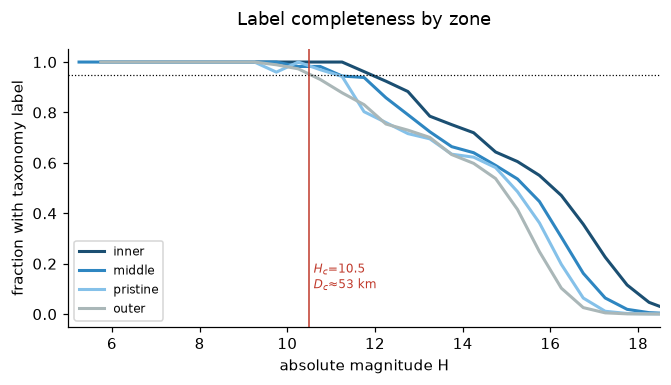

In [7]:
H_EDGES = np.arange(3, 19.5, 0.5)
mb["H_bin"] = pd.cut(mb.absolute_magnitude_h, H_EDGES)

def completeness(labelled):
    # fraction labelled per (H bin, zone); every category kept so codes index it directly
    g = mb.assign(lab=labelled).groupby(["H_bin", "zone"], observed=False).lab
    return g.mean().unstack(), g.size().unstack()

def complete_limit(comp, n):
    # faintest H edge such that every populated (H, zone) cell brighter than it is >= COMPLETE_FRAC labelled
    ok = ((comp >= COMPLETE_FRAC) | (n == 0)).all(axis=1) & (n.sum(axis=1) > 0)
    populated = n.sum(axis=1).values > 0
    bad = np.where(populated & ~ok.values)[0]
    return float(H_EDGES[bad[0]])

comp, ncount = completeness(mb.tier.eq("taxonomy"))
H_C = complete_limit(comp, ncount)
D_C = 1329 / np.sqrt(P_DARKEST) * 10 ** (-H_C / 5)
print(f"H_c = {H_C}  ->  D_complete = {D_C:.1f} km (p_dark = {P_DARKEST})")

fig, ax = plt.subplots(figsize=(6.2, 3.6))
mids = [iv.mid for iv in comp.index]
for z, c in zip(ZONE_NAMES, ["#1b4f72", "#2e86c1", "#85c1e9", "#aab7b8"]):
    ax.plot(mids, comp[z], color=c, lw=2, label=z)
ax.axhline(COMPLETE_FRAC, color="k", ls=":", lw=.8); ax.axvline(H_C, color="#c0392b", lw=1)
ax.text(H_C + .1, .1, f"$H_c$={H_C}\n$D_c$≈{D_C:.0f} km", color="#c0392b", fontsize=8)
ax.set(xlabel="absolute magnitude H", ylabel="fraction with taxonomy label", title="Label completeness by zone", xlim=(5, 18.5))
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / "fig0_completeness.png", dpi=200); plt.show()

hi_, zi_ = mb.H_bin.cat.codes.values, mb.zone.cat.codes.values
valid = (hi_ >= 0) & (zi_ >= 0)
mb["c"] = np.nan
mb.loc[valid, "c"] = comp.values[hi_[valid], zi_[valid]]
mb["w_ipw"] = np.where(mb.tier.eq("taxonomy") & (mb.absolute_magnitude_h < H_IPW_MAX) & (mb.c >= C_MIN_IPW), 1 / mb.c, 0.0)

## 5 · Composition vs heliocentric distance

Samples, each restricted to taxonomy-tier labels:

| sample | families | size / weighting |
|---|---|---|
| **raw** | kept | every labelled body, unweighted |
| **collapsed, IPW, D ≥ 10 km** | each family → one body (majority class) | size-limited, IPW-weighted |
| **collapsed, D ≥ D_c** | each family → one body | size-complete, unweighted |
| **background, D ≥ D_c** | removed entirely | size-complete, unweighted |

Uncertainty bands are Poisson-bootstrap 16–84% intervals.

In [8]:
def collapsed(df, ft):
    # background bodies + one synthetic row per classifiable family
    bg = df[~df.in_family]
    fr = ft[ft.fam_group.notna() & ft.a_rep.notna()]
    reps = pd.DataFrame({"semi_major_axis_au": fr.a_rep.values, "group": fr.fam_group.values,
                         "diameter_km": fr.D_equiv_km.values, "estimated_mass_kg": fr.mass_kg.values,
                         "e_p": fr.e_rep.values, "sini_p": fr.sini_rep.values,
                         "tier": "taxonomy", "w_ipw": 1.0, "in_family": True, "is_family_rep": True,
                         "name": fr.fam_name.values})
    out = pd.concat([bg.assign(is_family_rep=False), reps], ignore_index=True)
    out["zone"] = pd.cut(out.semi_major_axis_au, ZONES, labels=ZONE_NAMES)
    return out

def build_samples(df, ft):
    t = df[df.tier.eq("taxonomy")]
    col = collapsed(df, ft); col = col[col.tier.eq("taxonomy")]
    return {
        "raw":                        t.assign(w=1.0),
        f"collapsed, IPW, D≥{D_IPW:.0f} km": col[(col.w_ipw > 0) & (col.diameter_km >= D_IPW)].assign(w=col.w_ipw),
        f"collapsed, D≥{D_C:.0f} km": col[col.diameter_km >= D_C].assign(w=1.0),
        f"background, D≥{D_C:.0f} km": t[~t.in_family & (t.diameter_km >= D_C)].assign(w=1.0),
    }

NUM = {"narrow": ["C-like"], "broad": ["C-like", "D/P", "K/L"]}
DEN = {"narrow": ["S-like", "C-like"], "broad": ["S-like", "C-like", "D/P", "K/L"]}

def c_fraction_curve(s, which="narrow", edges=None, n_boot=N_BOOT):
    edges = np.arange(A_MIN, A_MAX + 1e-9, BIN_W) if edges is None else edges
    s = s[s.group.isin(DEN[which])]
    b = np.clip(np.digitize(s.semi_major_axis_au, edges) - 1, 0, len(edges) - 2)
    isC = s.group.isin(NUM[which]).values
    w = s.w.values
    nb = len(edges) - 1
    def frac(ww):
        num = np.bincount(b, ww * isC, nb); den = np.bincount(b, ww, nb)
        return np.where(den > 0, num / np.maximum(den, 1e-300), np.nan)
    f = frac(w)
    boots = np.array([frac(w * RNG.poisson(1.0, len(w))) for _ in range(n_boot)])
    lo, hi = np.nanpercentile(boots, [16, 84], axis=0)
    n = np.bincount(b, None, nb)
    return pd.DataFrame({"a": (edges[:-1] + edges[1:]) / 2, "f": f, "lo": lo, "hi": hi, "n": n})

def zone_table(samples, which="narrow"):
    rows = {}
    for k, s in samples.items():
        c = c_fraction_curve(s, which, edges=np.array(ZONES), n_boot=N_BOOT)
        rows[k] = [f"{f:.2f} [{l:.2f}–{h:.2f}] (n={n})" for f, l, h, n in zip(c.f, c.lo, c.hi, c.n)]
    return pd.DataFrame(rows, index=ZONE_NAMES).T

samples = build_samples(mb, ftab)
for k, s in samples.items():
    print(f"{k:32s} n={len(s):>8,}  effective weight={s.w.sum():>10,.0f}")

raw                              n= 161,646  effective weight=   161,646
collapsed, IPW, D≥10 km          n=   3,830  effective weight=     4,918
collapsed, D≥53 km               n=     492  effective weight=       492
background, D≥53 km              n=     405  effective weight=       405


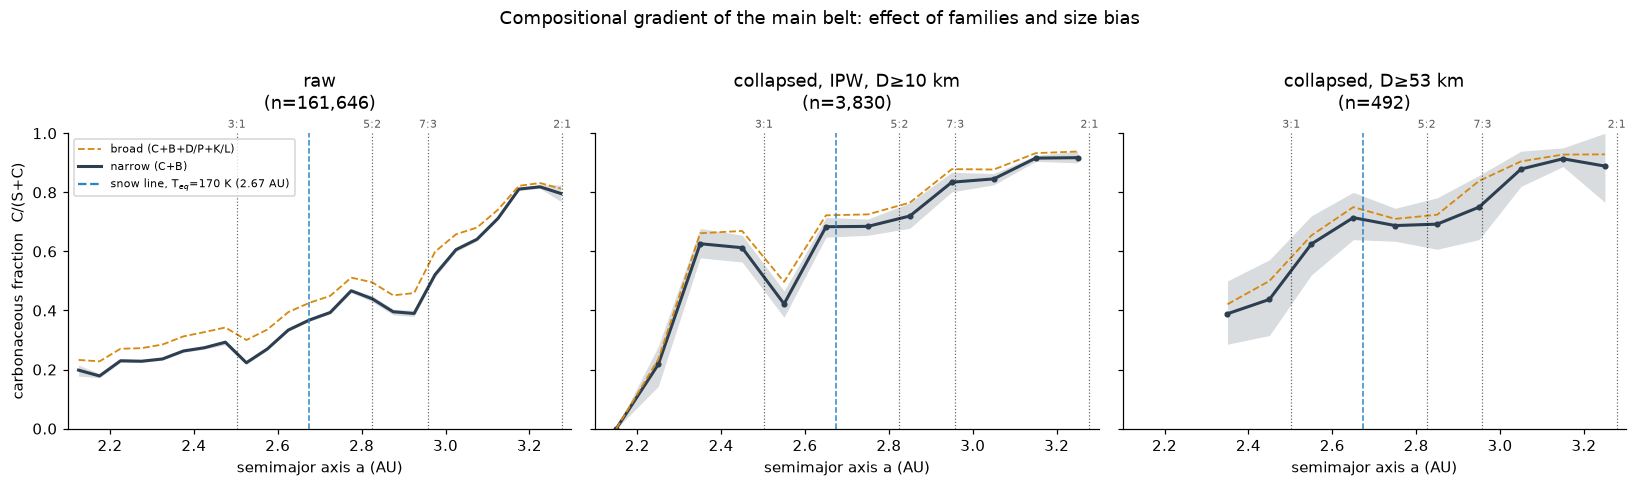

C-fraction by zone, NARROW definition  [16–84% bootstrap]


,inner,middle,pristine,outer
raw,0.25 [0.24–0.25] (n=49690),0.35 [0.34–0.35] (n=48943),0.40 [0.39–0.40] (n=5155),0.70 [0.69–0.70] (n=31581)
"collapsed, IPW, D≥10 km",0.52 [0.49–0.55] (n=231),0.63 [0.61–0.65] (n=661),0.77 [0.73–0.81] (n=128),0.90 [0.89–0.91] (n=1269)
"collapsed, D≥53 km",0.41 [0.31–0.49] (n=39),0.68 [0.64–0.73] (n=129),0.70 [0.61–0.77] (n=30),0.89 [0.87–0.92] (n=133)
"background, D≥53 km",0.46 [0.35–0.56] (n=24),0.71 [0.66–0.75] (n=96),0.71 [0.61–0.83] (n=21),0.91 [0.88–0.93] (n=106)


C-fraction by zone, BROAD definition


,inner,middle,pristine,outer
raw,0.29 [0.29–0.30] (n=53068),0.41 [0.40–0.41] (n=53852),0.46 [0.45–0.46] (n=5743),0.73 [0.73–0.73] (n=35198)
"collapsed, IPW, D≥10 km",0.57 [0.54–0.60] (n=258),0.68 [0.66–0.69] (n=751),0.82 [0.80–0.85] (n=167),0.92 [0.91–0.93] (n=1622)
"collapsed, D≥53 km",0.47 [0.38–0.53] (n=43),0.71 [0.67–0.75] (n=141),0.78 [0.72–0.84] (n=40),0.92 [0.89–0.94] (n=167)
"background, D≥53 km",0.52 [0.42–0.61] (n=27),0.74 [0.69–0.78] (n=107),0.81 [0.74–0.88] (n=31),0.93 [0.90–0.95] (n=139)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
panel_keys = ["raw", f"collapsed, IPW, D≥{D_IPW:.0f} km", f"collapsed, D≥{D_C:.0f} km"]
for ax, k in zip(axes, panel_keys):
    s = samples[k]
    sparse = k != "raw"   # weighted / size-limited samples are thin at 0.05 AU
    wide = 0.1 if sparse else BIN_W
    c = c_fraction_curve(s, "narrow", edges=np.arange(A_MIN, A_MAX + 1e-9, wide))
    ok = c.n >= (8 if sparse else 20)
    ax.fill_between(c.a[ok], c.lo[ok], c.hi[ok], color=COLORS["C-like"], alpha=.18, lw=0)
    ax.plot(c.a[ok], c.f[ok], color=COLORS["C-like"], lw=2, marker="o" if sparse else None, ms=3)
    cb = c_fraction_curve(s, "broad", edges=np.arange(A_MIN, A_MAX + 1e-9, wide), n_boot=20)
    ax.plot(cb.a[ok], cb.f[ok], color=COLORS["K/L"], lw=1.2, ls="--", label="broad (C+B+D/P+K/L)")
    mark_structure(ax)
    ax.set(title=f"{k}\n(n={len(s):,})", xlabel="semimajor axis a (AU)", ylim=(0, 1), xlim=(A_MIN, A_MAX))
axes[0].set_ylabel("carbonaceous fraction  C/(S+C)")
axes[0].plot([], [], color=COLORS["C-like"], lw=2, label="narrow (C+B)"); axes[0].plot([], [], color="#2e86c1", ls="--", label=f"snow line, T$_{{eq}}$=170 K ({SNOW_LINE_AU:.2f} AU)")
axes[0].legend(fontsize=7.5, loc="upper left")
fig.suptitle("Compositional gradient of the main belt: effect of families and size bias", y=1.02)
fig.tight_layout(); fig.savefig(FIG / "fig1_c_fraction_vs_a.png", dpi=200, bbox_inches="tight"); plt.show()

zt_narrow = zone_table(samples, "narrow"); zt_broad = zone_table(samples, "broad")
print("C-fraction by zone, NARROW definition  [16–84% bootstrap]"); display(zt_narrow)
print("C-fraction by zone, BROAD definition"); display(zt_broad)

### 5b · Stacked composition of the size-complete, family-collapsed sample

All five groups, not just the S/C ratio — shows where D/P and K/L bodies sit (the Levison et al. 2009 prediction puts D/P in the outer belt).

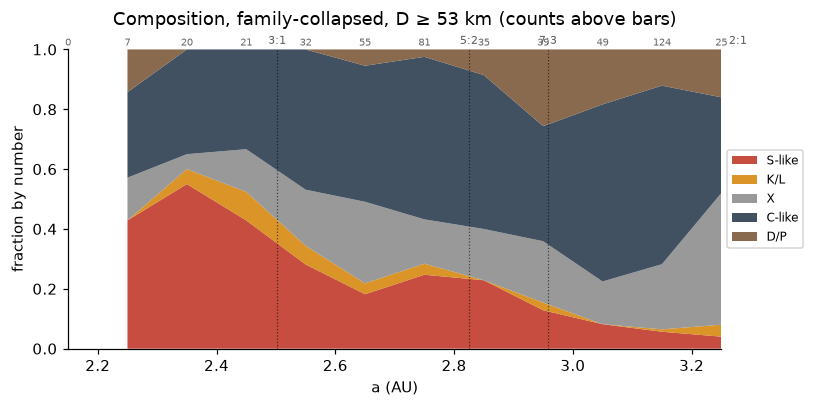

In [10]:
s = samples[f"collapsed, D≥{D_C:.0f} km"]
edges = np.arange(A_MIN, A_MAX + 1e-9, 0.1)
s = s.assign(bin=pd.cut(s.semi_major_axis_au, edges))
order = ["S-like", "K/L", "X", "C-like", "D/P"]
st = s[s.group.isin(order)].pivot_table(index="bin", columns="group", values="w", aggfunc="sum", observed=False).reindex(columns=order).fillna(0)
frac = st.div(st.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = [iv.mid for iv in frac.index]
ax.stackplot(x, [frac[g] for g in order], colors=[COLORS[g] for g in order], labels=order, alpha=.9)
for xi, n in zip(x, st.sum(axis=1)): ax.text(xi, 1.005, f"{int(n)}", ha="center", va="bottom", fontsize=6.5, color="0.4")
mark_structure(ax, snow=False)
ax.set(xlim=(A_MIN + .05, A_MAX - .05), ylim=(0, 1), xlabel="a (AU)", ylabel="fraction by number",
       title=f"Composition, family-collapsed, D ≥ {D_C:.0f} km (counts above bars)")
ax.legend(loc="center left", bbox_to_anchor=(1, .5), fontsize=8); fig.tight_layout()
fig.savefig(FIG / "fig1b_stacked_composition.png", dpi=200, bbox_inches="tight"); plt.show()

### 5c · Size dependence in the inner belt

For direct comparison with DeMeo & Carry (2014), who report that C-types hold only ~6% of inner-belt mass at large sizes but about half at the smallest sizes. Families are **included** here (as in their analysis), and the smallest bin is not debiased: at 5–20 km the taxonomic sample favours bright S-types, so its C-fraction is a lower limit.

In [11]:
inner = mb[mb.tier.eq("taxonomy") & mb.zone.eq("inner") & mb.group.isin(["S-like", "C-like"])]
rows = []
for lo, hi in [(100, np.inf), (50, 100), (20, 50), (5, 20)]:
    s = inner[(inner.diameter_km >= lo) & (inner.diameter_km < hi)]
    m = s.groupby("group").estimated_mass_kg.sum()
    rows.append(dict(size=f">= {lo} km" if np.isinf(hi) else f"{lo}-{hi} km",
                     n_S=int((s.group == "S-like").sum()), n_C=int((s.group == "C-like").sum()),
                     C_frac_number=(s.group == "C-like").mean(), C_frac_mass=m.get("C-like", 0) / m.sum()))
size_tab = pd.DataFrame(rows)
display(size_tab.round(3))

,size,n_S,n_C,C_frac_number,C_frac_mass
0,>= 100 km,10,3,0.231,0.039
1,50-100 km,16,18,0.529,0.460
2,20-50 km,25,37,0.597,0.372
3,5-20 km,1106,1068,0.491,0.340


## 6 · By mass

Mass is where the belt's formation budget actually sits. Masses are the catalog's `estimated_mass_kg` (measured where `mass_measured`, else class density × volume). Family collapse conserves mass, so this uses all taxonomy-labelled bodies. Because a handful of bodies dominate, the figure also shows the result with the four largest removed.

,name,semi_major_axis_au,spectral_type,group,diameter_km,estimated_mass_kg,mass_measured,share_of_labelled_mass
868878,Ceres,2.766,C,C-like,939.400,9.384000e+20,True,0.384
244250,Vesta,2.361,V,S-like,522.770,2.590000e+20,True,0.106
876333,Pallas,2.770,B,C-like,513.000,2.052555e+20,True,0.084
1306500,Hygiea,3.151,C,C-like,407.120,8.217293e+19,True,0.034
1125540,Interamnia,3.057,B,C-like,306.313,3.227403e+19,True,0.013
641451,Eunomia,2.642,S,S-like,231.689,3.197211e+19,True,0.013
1329373,Davida,3.162,C,C-like,270.327,3.133410e+19,True,0.013
701097,Juno,2.671,Sk,S-like,246.596,2.706739e+19,True,0.011
1193116,Europa,3.094,C,C-like,303.918,2.688263e+19,True,0.011
993218,Psyche,2.926,X,X,222.000,2.410029e+19,True,0.010


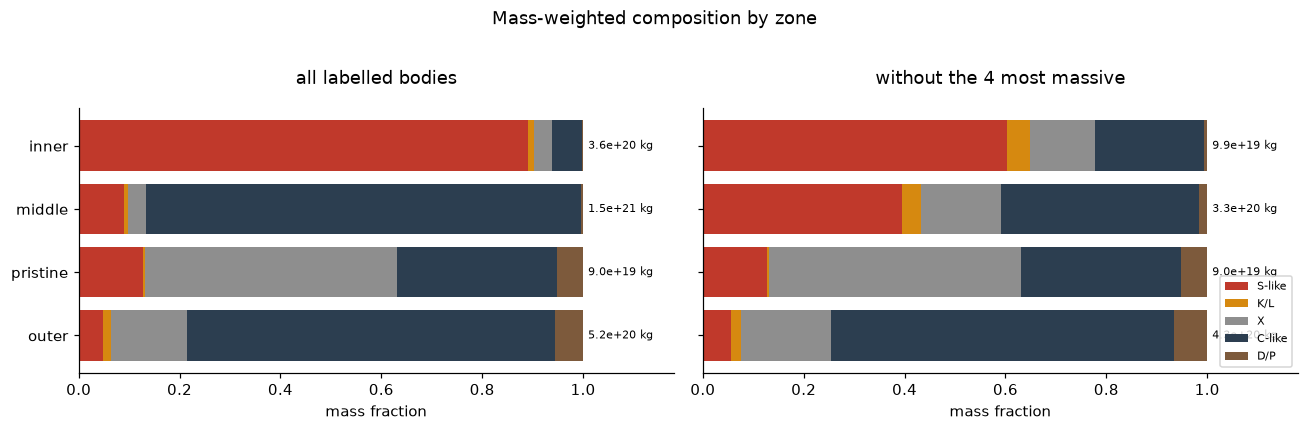

mass-weighted narrow C-fraction by zone: {'all': {'inner': 0.063, 'middle': 0.906, 'pristine': 0.715, 'outer': 0.939}, 'no_big4': {'inner': 0.263, 'middle': 0.499, 'pristine': 0.715, 'outer': 0.923}}


In [12]:
t = mb[mb.tier.eq("taxonomy") & mb.estimated_mass_kg.notna() & mb.group.isin(order)]
top = t.nlargest(10, "estimated_mass_kg")[["name", "semi_major_axis_au", "spectral_type", "group", "diameter_km", "estimated_mass_kg", "mass_measured"]]
top["share_of_labelled_mass"] = top.estimated_mass_kg / t.estimated_mass_kg.sum()
display(top.round(3))

big4 = set(t.nlargest(4, "estimated_mass_kg").index)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (lab, d) in zip(axes, [("all labelled bodies", t), ("without the 4 most massive", t.drop(index=list(big4)))]):
    mz = d.pivot_table(index="zone", columns="group", values="estimated_mass_kg", aggfunc="sum", observed=False).reindex(columns=order).fillna(0)
    fz = mz.div(mz.sum(axis=1), axis=0)
    left = np.zeros(len(fz))
    for g in order:
        ax.barh(ZONE_NAMES, fz[g], left=left, color=COLORS[g], label=g); left += fz[g].values
    for i, z in enumerate(ZONE_NAMES):
        ax.text(1.01, i, f"{mz.loc[z].sum():.1e} kg", va="center", fontsize=7.5)
    ax.set(title=lab, xlim=(0, 1.18), xlabel="mass fraction")
axes[0].invert_yaxis(); axes[1].legend(fontsize=7.5, loc="lower right")
fig.suptitle("Mass-weighted composition by zone", y=1.02); fig.tight_layout()
fig.savefig(FIG / "fig2_mass_by_zone.png", dpi=200, bbox_inches="tight"); plt.show()

mass_c = {}
for lab, d in [("all", t), ("no_big4", t.drop(index=list(big4)))]:
    mz = d.pivot_table(index="zone", columns="group", values="estimated_mass_kg", aggfunc="sum", observed=False).reindex(columns=order).fillna(0)
    mass_c[lab] = (mz["C-like"] / (mz["C-like"] + mz["S-like"])).round(3).to_dict()
print("mass-weighted narrow C-fraction by zone:", mass_c)

## 7 · Where do S and C cross over?

Fit a logistic model $P(\mathrm{C}\mid a) = [1+e^{-(\beta_0+\beta_1(a-2.7))}]^{-1}$ by weighted maximum likelihood to S-like vs C-like bodies, and report $a_{50} = 2.7 - \beta_0/\beta_1$ and the 10→90% transition width $4.39/\beta_1$ with bootstrap CIs.

A *static, in-situ* nebula predicts a narrow transition centred on the condensation front. A transition comparable to or **wider than the belt itself** is the signature of mixing. The crossover landing near 2.7 AU is **not** evidence for a primordial snow line: the snow line moved inward as the star and disk cooled, and the bodies moved after they formed.

In [13]:
def fit_logistic(a, y, w):
    x = a - 2.7
    def nll(b):
        z = b[0] + b[1] * x
        return -np.sum(w * (y * z - np.logaddexp(0, z)))
    return optimize.minimize(nll, [0.0, 3.0], method="BFGS").x

def crossover(s, n_boot=200):
    s = s[s.group.isin(["S-like", "C-like"])]
    if len(s) < 20 or s.group.nunique() < 2:
        return dict(a50=np.nan, a50_lo=np.nan, a50_hi=np.nan, width_10_90=np.nan, width_lo=np.nan, width_hi=np.nan, n=len(s))
    a, y, w = s.semi_major_axis_au.values, s.group.eq("C-like").values.astype(float), s.w.values
    b = fit_logistic(a, y, w)
    bs = np.array([fit_logistic(a, y, w * RNG.poisson(1.0, len(w))) for _ in range(n_boot)])
    a50 = 2.7 - bs[:, 0] / bs[:, 1]; width = 4.394 / bs[:, 1]
    return dict(a50=2.7 - b[0] / b[1], a50_lo=np.percentile(a50, 16), a50_hi=np.percentile(a50, 84),
                width_10_90=4.394 / b[1], width_lo=np.percentile(width, 16), width_hi=np.percentile(width, 84), n=len(s))

xo = pd.DataFrame({k: crossover(s) for k, s in samples.items()}).T
display(xo.round(3))
print(f"snow line (T_eq = 170 K): {SNOW_LINE_AU:.2f} AU;   main-belt width {A_MAX - A_MIN:.1f} AU")

,a50,a50_lo,a50_hi,width_10_90,width_lo,width_hi,n
raw,2.841,2.838,2.844,1.717,1.705,1.733,135369.0
"collapsed, IPW, D≥10 km",2.463,2.430,2.485,1.379,1.315,1.472,2289.0
"collapsed, D≥53 km",2.472,2.392,2.516,1.391,1.203,1.684,331.0
"background, D≥53 km",2.407,2.308,2.482,1.486,1.228,1.848,247.0


snow line (T_eq = 170 K): 2.67 AU;   main-belt width 1.2 AU


## 8 · Orbital excitation: are inner-belt C-types dynamically different?

If C-types in the inner belt were **implanted** from beyond Jupiter while S-types formed nearby (or were implanted from the terrestrial zone by a different path), their proper eccentricities and inclinations need not match. Formed-in-place predicts no class dependence within a zone. This is the discriminating test the paper can contribute.

Sample: **background only** (family members share near-identical proper elements and would dominate), taxonomy tier, $D \ge$ `D_ORBIT`, with proper elements. Two-sample Kolmogorov–Smirnov test per zone and element (8 tests → Bonferroni threshold $p<0.00625$); median differences with 95% bootstrap CIs.

Interpretive caution: resonances and secular resonances (ν6 near the inner edge) sculpt *e* and *i* for everyone after the fact, and Yarkovsky drift is size-dependent — so a difference is suggestive, and its absence does not rule out implantation (Raymond & Izidoro 2017 predict implanted populations are stirred together).

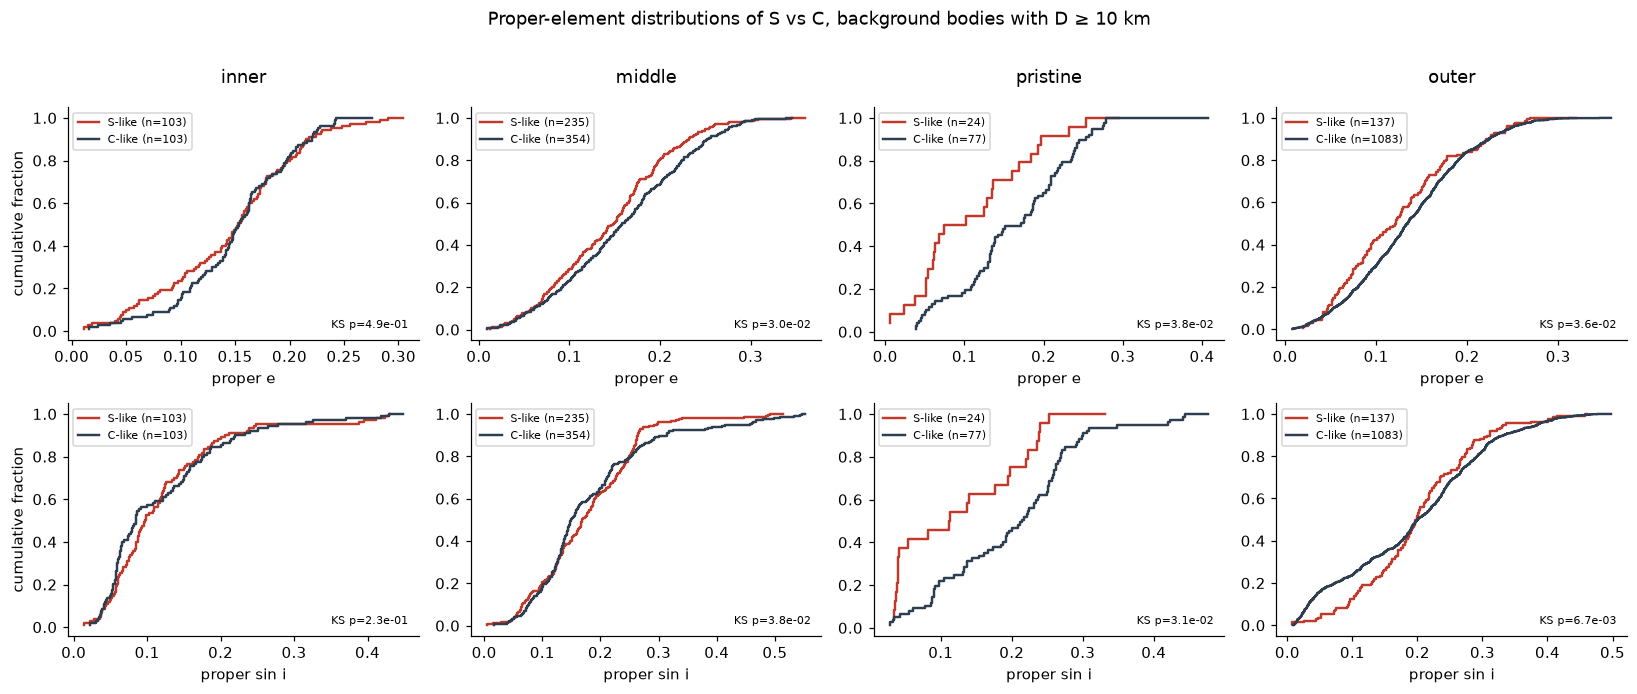

,zone,element,n_S,n_C,median_S,median_C,dmedian_C_minus_S,ci95_lo,ci95_hi,KS_D,KS_p,bonferroni_sig
0,inner,proper e,103,103,0.1555,0.1542,-0.0014,-0.0128,0.0159,0.1165,0.4887,False
1,inner,proper sin i,103,103,0.0983,0.0852,-0.0131,-0.0366,0.0238,0.1456,0.2254,False
2,middle,proper e,235,354,0.1499,0.1596,0.0097,-0.0046,0.0291,0.1202,0.0304,False
3,middle,proper sin i,235,354,0.1704,0.1498,-0.0206,-0.0378,-0.0045,0.1168,0.0382,False
4,pristine,proper e,24,77,0.1133,0.1752,0.0619,-0.0005,0.1219,0.3182,0.0378,False
5,pristine,proper sin i,24,77,0.1251,0.2169,0.0918,0.0051,0.1693,0.3258,0.0311,False
6,outer,proper e,137,1083,0.1215,0.1346,0.0131,-0.0037,0.0363,0.1270,0.0357,False
7,outer,proper sin i,137,1083,0.1994,0.2005,0.0011,-0.0147,0.0191,0.1514,0.0067,False


In [14]:
orb = mb[mb.tier.eq("taxonomy") & ~mb.in_family & (mb.diameter_km >= D_ORBIT) & mb.e_p.notna() & mb.group.isin(["S-like", "C-like"])]

def med_diff_ci(x, y, n=1000):
    d = [np.median(RNG.choice(x, len(x))) - np.median(RNG.choice(y, len(y))) for _ in range(n)]
    return np.median(x) - np.median(y), *np.percentile(d, [2.5, 97.5])

rows = []
fig, axes = plt.subplots(2, 4, figsize=(15, 6.2))
for j, z in enumerate(ZONE_NAMES):
    oz = orb[orb.zone == z]
    for i, (col, lab) in enumerate([("e_p", "proper e"), ("sini_p", "proper sin i")]):
        S = oz.loc[oz.group == "S-like", col].values; C = oz.loc[oz.group == "C-like", col].values
        ax = axes[i, j]
        for arr, g in [(S, "S-like"), (C, "C-like")]:
            if len(arr): ax.step(np.sort(arr), np.arange(1, len(arr) + 1) / len(arr), color=COLORS[g], lw=1.6, label=f"{g} (n={len(arr)})")
        if len(S) >= 10 and len(C) >= 10:
            ks = stats.ks_2samp(S, C)
            md_, lo, hi = med_diff_ci(C, S)
            rows.append(dict(zone=z, element=lab, n_S=len(S), n_C=len(C), median_S=np.median(S), median_C=np.median(C),
                             dmedian_C_minus_S=md_, ci95_lo=lo, ci95_hi=hi, KS_D=ks.statistic, KS_p=ks.pvalue))
            ax.text(.97, .05, f"KS p={ks.pvalue:.1e}", transform=ax.transAxes, ha="right", fontsize=7.5)
        ax.set(xlabel=lab, ylabel="cumulative fraction" if j == 0 else None, title=z if i == 0 else None)
        ax.legend(fontsize=7, loc="upper left")
fig.suptitle(f"Proper-element distributions of S vs C, background bodies with D ≥ {D_ORBIT:.0f} km", y=1.01)
fig.tight_layout(); fig.savefig(FIG / "fig3_orbital_excitation.png", dpi=200, bbox_inches="tight"); plt.show()
orbit_tests = pd.DataFrame(rows)
orbit_tests["bonferroni_sig"] = orbit_tests.KS_p < 0.05 / len(orbit_tests)   # 8 tests -> p < 0.00625
display(orbit_tests.round(4))

## 9 · Robustness

**(a)** Narrow vs broad carbonaceous definition — already shown in Fig 1 and the zone tables.

**(b) Label-free check.** Forget taxonomy: use only **measured** geometric albedo (NEOWISE/JPL) and call $p_V<0.10$ "dark". Completeness of measured albedos is computed the same way as §4.

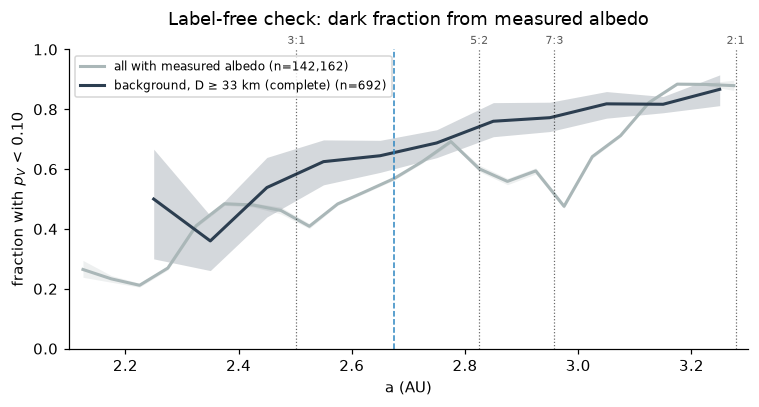

albedo completeness: H_c = 11.5, D_c = 33.3 km


,mean,size
zone,,
inner,0.450,60
middle,0.658,225
pristine,0.789,71
outer,0.821,336


In [15]:
alb = mb[mb.albedo.notna()].copy()
compA, nA = completeness(mb.albedo.notna())
H_CA = complete_limit(compA, nA)
D_CA = 1329 / np.sqrt(P_DARKEST) * 10 ** (-H_CA / 5)
alb["dark"] = alb.albedo < 0.10

def dark_curve(d, edges):
    b = np.clip(np.digitize(d.semi_major_axis_au, edges) - 1, 0, len(edges) - 2); nb = len(edges) - 1
    y = d.dark.values.astype(float)
    f = lambda w: np.bincount(b, w * y, nb) / np.maximum(np.bincount(b, w, nb), 1e-300)
    boots = np.array([f(RNG.poisson(1.0, len(y)).astype(float)) for _ in range(N_BOOT)])
    return (edges[:-1] + edges[1:]) / 2, f(np.ones(len(y))), *np.percentile(boots, [16, 84], axis=0), np.bincount(b, None, nb)

fig, ax = plt.subplots(figsize=(7, 3.8))
for lab, d, c in [("all with measured albedo", alb, "#aab7b8"),
                  (f"background, D ≥ {D_CA:.0f} km (complete)", alb[~alb.in_family & (alb.diameter_km >= D_CA)], COLORS["C-like"])]:
    x, f, lo, hi, n = dark_curve(d, np.arange(A_MIN, A_MAX + 1e-9, 0.1 if "D ≥" in lab else BIN_W))
    k = n >= 5
    ax.fill_between(x[k], lo[k], hi[k], color=c, alpha=.2, lw=0); ax.plot(x[k], f[k], color=c, lw=2, label=f"{lab} (n={len(d):,})")
mark_structure(ax)
ax.set(xlabel="a (AU)", ylabel="fraction with $p_V$ < 0.10", ylim=(0, 1), xlim=(A_MIN, A_MAX), title="Label-free check: dark fraction from measured albedo")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / "fig4_dark_fraction_albedo.png", dpi=200); plt.show()
dark_zone = alb[~alb.in_family & (alb.diameter_km >= D_CA)].groupby("zone", observed=False).dark.agg(["mean", "size"])
print(f"albedo completeness: H_c = {H_CA}, D_c = {D_CA:.1f} km"); display(dark_zone.round(3))

**(c) Family extension on/off.** Re-run the zone table and crossover with the one-step extension toggled.

In [16]:
alt = mb.copy()
alt["fam_id"] = alt.key.map(fam_base if EXTEND_FAMILIES else fam_ext)
alt["in_family"] = alt.fam_id.notna()
alt_samples = build_samples(alt, family_table(alt))
fmt = lambda zt: zt.apply(lambda r: " / ".join(v.split(" ")[0] for v in r), axis=1)
cmp = pd.DataFrame({"baseline": fmt(zone_table(samples)), "extension toggled": fmt(zone_table(alt_samples))})
cmp.columns = [f"{c}  (C-frac inner / middle / pristine / outer)" for c in cmp.columns]
print(f"EXTEND_FAMILIES baseline = {EXTEND_FAMILIES}; the extension attaches {n_added:,} bodies")
display(cmp)
xo_alt = pd.DataFrame({k: crossover(s_, n_boot=100) for k, s_ in alt_samples.items()}).T
display(xo_alt[["a50", "a50_lo", "a50_hi", "width_10_90"]].round(3))

EXTEND_FAMILIES baseline = False; the extension attaches 229,745 bodies


,baseline (C-frac inner / middle / pristine / outer),extension toggled (C-frac inner / middle / pristine / outer)
raw,0.25 / 0.35 / 0.40 / 0.70,0.25 / 0.35 / 0.40 / 0.70
"collapsed, IPW, D≥10 km",0.52 / 0.63 / 0.77 / 0.90,0.53 / 0.63 / 0.78 / 0.89
"collapsed, D≥53 km",0.41 / 0.68 / 0.70 / 0.89,0.41 / 0.66 / 0.71 / 0.90
"background, D≥53 km",0.46 / 0.71 / 0.71 / 0.91,0.45 / 0.70 / 0.71 / 0.91


,a50,a50_lo,a50_hi,width_10_90
raw,2.841,2.838,2.843,1.717
"collapsed, IPW, D≥10 km",2.454,2.429,2.478,1.425
"collapsed, D≥53 km",2.500,2.436,2.553,1.314
"background, D≥53 km",2.420,2.307,2.504,1.461


**(d) The circularity trap, demonstrated.** Plot the C-fraction using the `albedo_assumed` tier. Its labels come from an albedo chosen *by semimajor-axis band*, so it returns a step function at the band edges — a gradient that exists only because the pipeline assumed it. This is why §1 excludes that tier; it belongs in the paper's methods section.

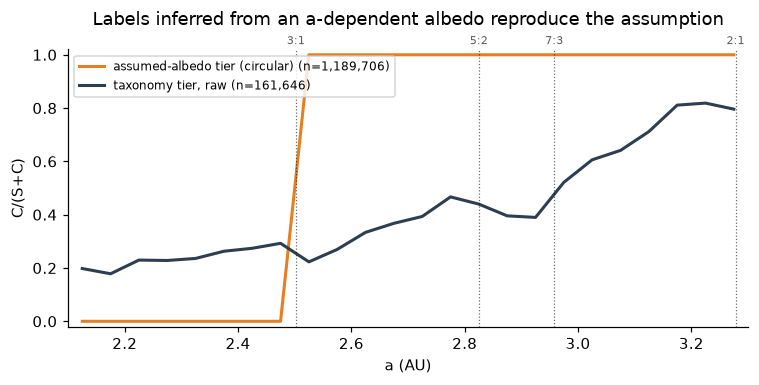

In [17]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for lab, d, c in [("assumed-albedo tier (circular)", mb[mb.tier.eq("assumed")].assign(w=1.0), "#e67e22"),
                  ("taxonomy tier, raw", samples["raw"], COLORS["C-like"])]:
    cc = c_fraction_curve(d, "narrow", n_boot=50)
    ax.plot(cc.a, cc.f, color=c, lw=2, label=f"{lab} (n={len(d):,})")
mark_structure(ax, snow=False)
ax.set(xlabel="a (AU)", ylabel="C/(S+C)", ylim=(-.02, 1.02), xlim=(A_MIN, A_MAX), title="Labels inferred from an a-dependent albedo reproduce the assumption")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(FIG / "fig5_circularity.png", dpi=200); plt.show()

## 10 · Summary numbers

Written to `results/summary.json` so the paper draft can quote them without re-running.

In [18]:
summary = {
    "catalog": {"rows": int(len(cat)), "catalog_date": str(cat.catalog_date.iloc[0]), "pipeline_version": str(cat.pipeline_version.iloc[0]),
                "main_belt": int(len(mb)), "taxonomy_tier": int(mb.tier.eq("taxonomy").sum())},
    "families": {"n_families": int(len(fams)), "members_matched_main_belt": int(mb.in_family.sum()),
                 "family_fraction": round(float(mb.in_family.mean()), 4), "extension_attaches": n_added, "extension_used": EXTEND_FAMILIES},
    "completeness": {"H_c": H_C, "D_complete_km": round(D_C, 1), "H_c_albedo": H_CA, "D_complete_albedo_km": round(D_CA, 1)},
    "zone_c_fraction_narrow": zt_narrow.to_dict(), "zone_c_fraction_broad": zt_broad.to_dict(),
    "mass_c_fraction": mass_c,
    "inner_belt_by_size": size_tab.round(4).to_dict(orient="records"),
    "crossover": xo.round(4).to_dict(orient="index"),
    "snow_line_au": round(SNOW_LINE_AU, 3),
    "orbit_tests": orbit_tests.round(5).to_dict(orient="records"),
    "dark_fraction_complete": dark_zone["mean"].round(4).to_dict(),
}
(RES / "summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps({k: summary[k] for k in ["families", "completeness", "crossover"]}, indent=2, default=str))

{
  "families": {
    "n_families": 272,
    "members_matched_main_belt": 153271,
    "family_fraction": 0.1071,
    "extension_attaches": 229745,
    "extension_used": false
  },
  "completeness": {
    "H_c": 10.5,
    "D_complete_km": 52.8,
    "H_c_albedo": 11.5,
    "D_complete_albedo_km": 33.3
  },
  "crossover": {
    "raw": {
      "a50": 2.8407,
      "a50_lo": 2.8382,
      "a50_hi": 2.8442,
      "width_10_90": 1.7168,
      "width_lo": 1.7052,
      "width_hi": 1.7327,
      "n": 135369.0
    },
    "collapsed, IPW, D\u226510 km": {
      "a50": 2.4629,
      "a50_lo": 2.4298,
      "a50_hi": 2.4849,
      "width_10_90": 1.3786,
      "width_lo": 1.3148,
      "width_hi": 1.4724,
      "n": 2289.0
    },
    "collapsed, D\u226553 km": {
      "a50": 2.4721,
      "a50_lo": 2.3925,
      "a50_hi": 2.5165,
      "width_10_90": 1.3915,
      "width_lo": 1.2034,
      "width_hi": 1.6841,
      "n": 331.0
    },
    "background, D\u226553 km": {
      "a50": 2.4068,
      "a50_l